Using device: cuda
Background Robustness Experiment

Creating datasets...

Training CNN...
Epoch [5/30], Loss: 0.0000, Val Acc: 100.00%
Epoch [10/30], Loss: 0.0000, Val Acc: 100.00%
Epoch [15/30], Loss: 0.0000, Val Acc: 100.00%
Epoch [20/30], Loss: 0.0002, Val Acc: 100.00%
Epoch [25/30], Loss: 0.0000, Val Acc: 100.00%
Epoch [30/30], Loss: 0.0000, Val Acc: 100.00%

Evaluating CNN on different test sets:

CNN (Uniform BG) Test Accuracy: 100.00%

CNN (Varied BG) Test Accuracy: 90.33%

CNN (Augmented BG) Test Accuracy: 87.33%

Training Fully Connected Network...
Epoch [5/30], Loss: 0.0358, Val Acc: 100.00%
Epoch [10/30], Loss: 0.0126, Val Acc: 100.00%
Epoch [15/30], Loss: 0.0111, Val Acc: 100.00%
Epoch [20/30], Loss: 0.0127, Val Acc: 100.00%
Epoch [25/30], Loss: 0.0105, Val Acc: 100.00%
Epoch [30/30], Loss: 0.0111, Val Acc: 100.00%

Evaluating FC on different test sets:

FC (Uniform BG) Test Accuracy: 100.00%

FC (Varied BG) Test Accuracy: 100.00%

FC (Augmented BG) Test Accuracy: 99.33%



/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 162MB/s]


Epoch [5/15], Loss: 0.0005, Val Acc: 100.00%
Epoch [10/15], Loss: 0.0003, Val Acc: 100.00%
Epoch [15/15], Loss: 0.0002, Val Acc: 100.00%

Evaluating Fine-tuned Model on different test sets:

Fine-tuned (Uniform BG) Test Accuracy: 100.00%

Fine-tuned (Varied BG) Test Accuracy: 40.67%

Fine-tuned (Augmented BG) Test Accuracy: 43.00%

Results Summary


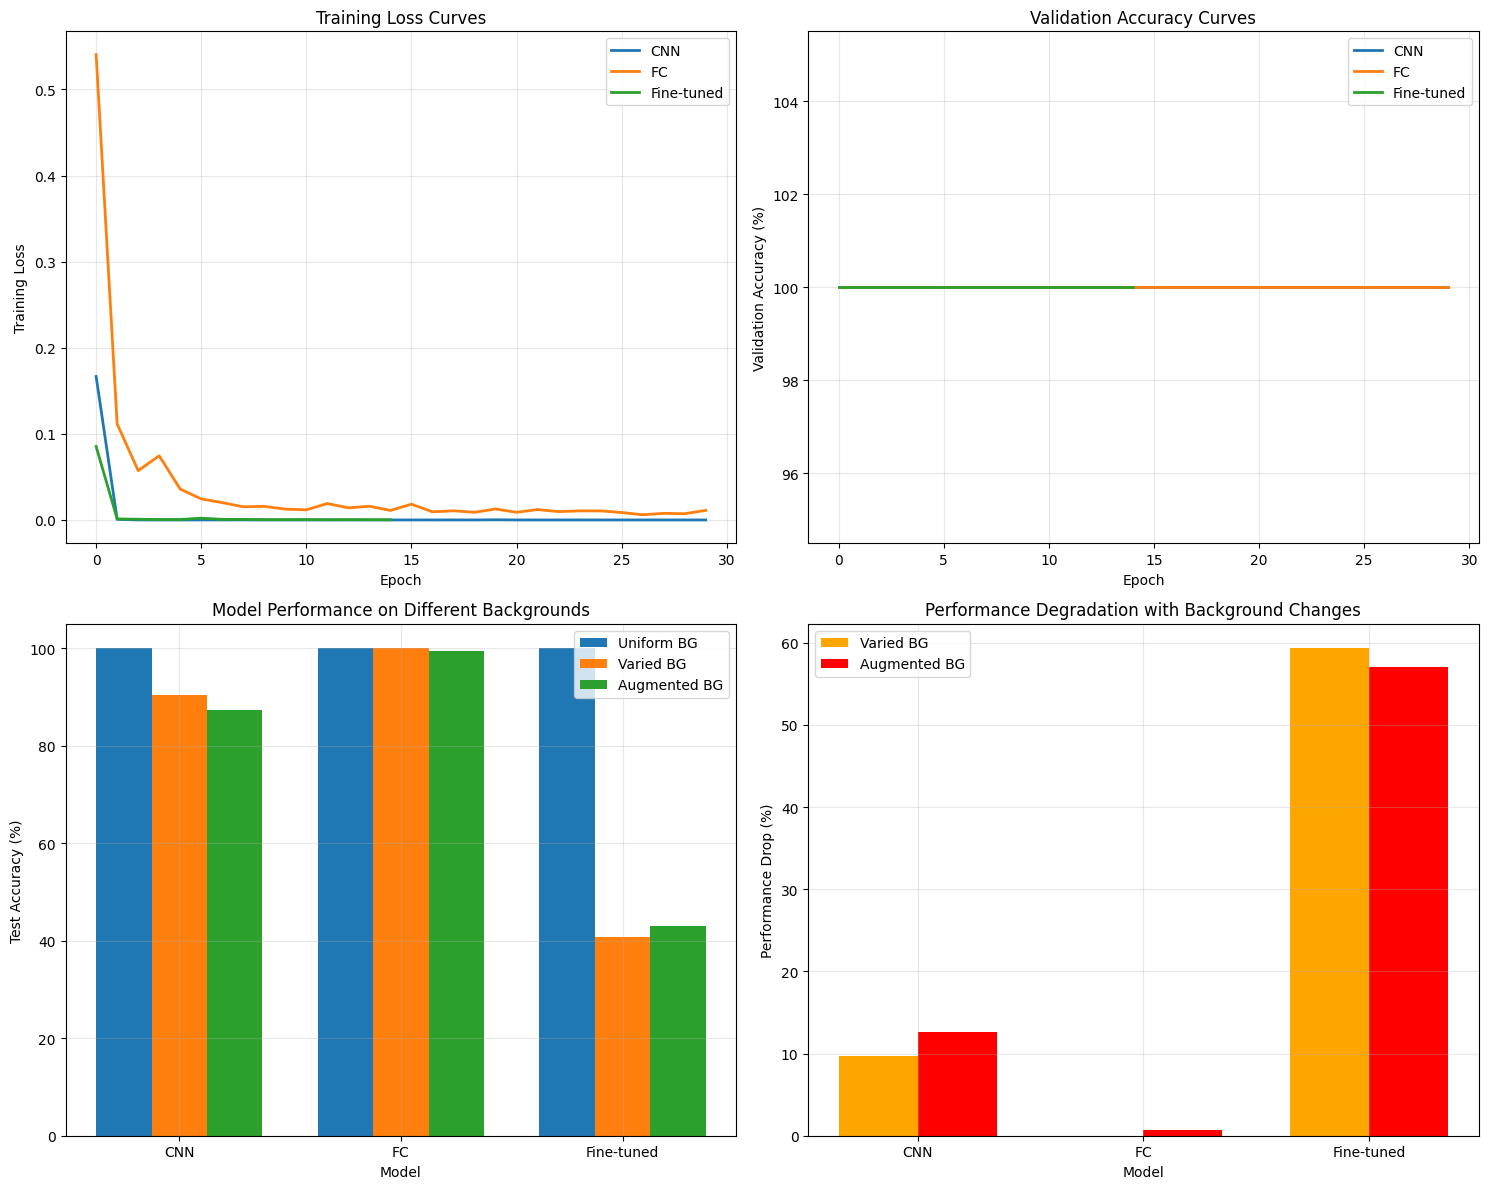


Detailed Results:
------------------------------------------------------------
Model           Uniform BG      Varied BG       Augmented BG   
------------------------------------------------------------
CNN                     100.00%          90.33%          87.33%
FC                      100.00%         100.00%          99.33%
Fine-tuned              100.00%          40.67%          43.00%

Key Observations:
1. CNN vs FC: CNNs typically show better robustness to background changes
   due to their spatial feature extraction capabilities.
2. Fine-tuning: Pre-trained models often generalize better to
   distribution shifts, even with limited fine-tuning data.
3. Background Impact: Performance degradation demonstrates the
   importance of diverse training data for real-world deployment.

Additional Analysis: Progressive Augmentation Test

Testing CNN with progressive augmentation:
Severity 0.1: Accuracy = 20.00%
Severity 0.3: Accuracy = 20.00%
Severity 0.5: Accuracy = 20.00%
Severity 0

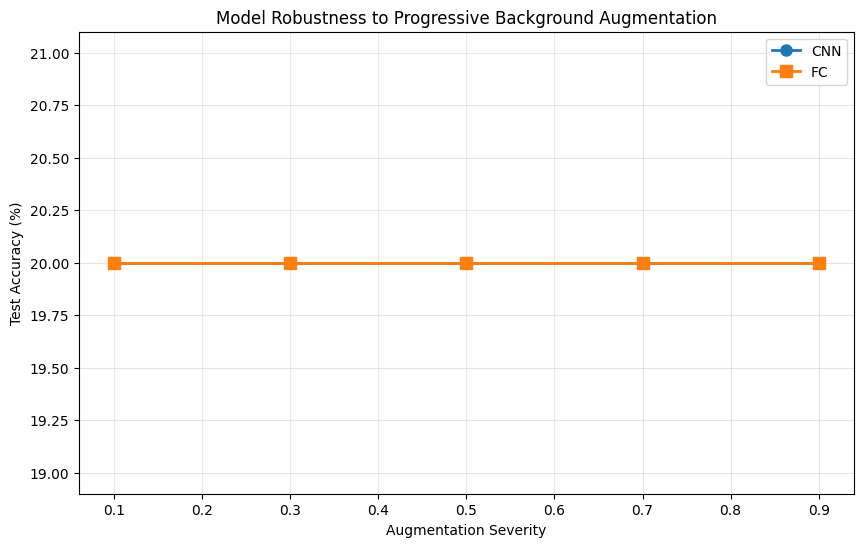


Experiment Complete!


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision
import torchvision.transforms as transforms
from torchvision import models
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
from PIL import Image
import random

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ===================== Custom Dataset with Background Control =====================
class BackgroundControlledDataset(Dataset):
    """
    Custom dataset that creates synthetic data with controlled backgrounds.
    For training: uniform background
    For testing: various augmented backgrounds
    """
    def __init__(self, mode='train', num_samples=1000, img_size=64, num_classes=10):
        self.mode = mode
        self.num_samples = num_samples
        self.img_size = img_size
        self.num_classes = num_classes

        # Generate synthetic data
        self.data = []
        self.labels = []

        for i in range(num_samples):
            label = i % num_classes
            img = self._generate_sample(label)
            self.data.append(img)
            self.labels.append(label)

    def _generate_sample(self, label):
        """Generate a synthetic image with controlled background"""
        img = np.zeros((3, self.img_size, self.img_size), dtype=np.float32)

        # Create background
        if self.mode == 'train':
            # Uniform gray background for training
            img[:] = 0.5
        else:
            # Varied backgrounds for testing
            bg_type = np.random.choice(['gradient', 'noise', 'pattern', 'color'])
            if bg_type == 'gradient':
                for i in range(self.img_size):
                    img[:, i, :] = i / self.img_size
            elif bg_type == 'noise':
                img[:] = np.random.rand(3, self.img_size, self.img_size) * 0.3
            elif bg_type == 'pattern':
                for i in range(0, self.img_size, 8):
                    img[:, i:i+4, :] = 0.7
                    img[:, :, i:i+4] = 0.3
            else:  # color
                img[0] = np.random.rand() * 0.5
                img[1] = np.random.rand() * 0.5
                img[2] = np.random.rand() * 0.5

        # Add foreground object (simple shapes for different classes)
        center = self.img_size // 2
        size = self.img_size // 4

        if label == 0:  # Circle
            y, x = np.ogrid[-center:self.img_size-center, -center:self.img_size-center]
            mask = x*x + y*y <= size*size
            img[:, mask] = 1.0
        elif label == 1:  # Square
            img[:, center-size:center+size, center-size:center+size] = 1.0
        elif label == 2:  # Triangle
            for i in range(size*2):
                for j in range(i+1):
                    if center-size+i < self.img_size and center-j < self.img_size:
                        img[:, center-size+i, center-j:center+j+1] = 1.0
        elif label == 3:  # Cross
            img[:, center-2:center+2, :] = 1.0
            img[:, :, center-2:center+2] = 1.0
        elif label == 4:  # Diamond
            for i in range(size):
                img[:, center-i:center+i+1, center-size+i] = 1.0
                img[:, center-i:center+i+1, center+size-i] = 1.0
        else:  # Random pattern for other classes
            np.random.seed(label)
            pattern = np.random.rand(size*2, size*2) > 0.5
            img[:, center-size:center+size, center-size:center+size] = pattern
            np.random.seed(None)

        return torch.FloatTensor(img)

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]

# ===================== Data Augmentation for Background Changes =====================
class BackgroundAugmentation:
    """Custom augmentation to change backgrounds"""
    def __init__(self, severity=0.5):
        self.severity = severity

    def __call__(self, img):
        if not isinstance(img, torch.Tensor):
            img = transforms.ToTensor()(img)

        aug_type = random.choice(['blur', 'noise', 'color_shift', 'texture'])

        if aug_type == 'blur':
            # Apply Gaussian blur to background
            kernel_size = int(5 + self.severity * 10)
            if kernel_size % 2 == 0:
                kernel_size += 1
            img = transforms.GaussianBlur(kernel_size, sigma=(0.1, 2.0))(img)
        elif aug_type == 'noise':
            # Add Gaussian noise
            noise = torch.randn_like(img) * self.severity * 0.2
            img = torch.clamp(img + noise, 0, 1)
        elif aug_type == 'color_shift':
            # Shift colors
            shift = torch.randn(3, 1, 1) * self.severity * 0.3
            img = torch.clamp(img + shift, 0, 1)
        else:  # texture
            # Add texture pattern
            texture = torch.rand_like(img) * self.severity * 0.3
            img = torch.clamp(img * (1 - self.severity * 0.5) + texture, 0, 1)

        return img

# ===================== Model Architectures =====================

class SimpleCNN(nn.Module):
    """Simple CNN architecture"""
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.5)

        # Calculate the size after convolutions and pooling
        self.fc1 = nn.Linear(128 * 8 * 8, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

class FullyConnectedNet(nn.Module):
    """Fully connected network (MLP)"""
    def __init__(self, input_size=64*64*3, num_classes=10):
        super(FullyConnectedNet, self).__init__()
        self.fc1 = nn.Linear(input_size, 512)
        self.bn1 = nn.BatchNorm1d(512)
        self.fc2 = nn.Linear(512, 256)
        self.bn2 = nn.BatchNorm1d(256)
        self.fc3 = nn.Linear(256, 128)
        self.bn3 = nn.BatchNorm1d(128)
        self.fc4 = nn.Linear(128, num_classes)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.bn1(self.fc1(x))))
        x = self.dropout(F.relu(self.bn2(self.fc2(x))))
        x = self.dropout(F.relu(self.bn3(self.fc3(x))))
        x = self.fc4(x)
        return x

class PretrainedCNN(nn.Module):
    """Pretrained ResNet18 for fine-tuning"""
    def __init__(self, num_classes=10, freeze_backbone=False):
        super(PretrainedCNN, self).__init__()
        self.backbone = models.resnet18(pretrained=True)

        # Freeze backbone if specified
        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False

        # Replace the final layer
        num_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(num_features, num_classes)

    def forward(self, x):
        # Resize input if needed (ResNet expects at least 224x224)
        if x.size(-1) < 224:
            x = F.interpolate(x, size=(224, 224), mode='bilinear', align_corners=False)
        return self.backbone(x)

# ===================== Training and Evaluation Functions =====================

def train_model(model, train_loader, val_loader, epochs=20, lr=0.001):
    """Train the model"""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

    train_losses = []
    val_accuracies = []

    for epoch in range(epochs):
        # Training phase
        model.train()
        running_loss = 0.0
        for i, (inputs, labels) in enumerate(train_loader):
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        # Validation phase
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_acc = 100 * correct / total
        avg_loss = running_loss / len(train_loader)
        train_losses.append(avg_loss)
        val_accuracies.append(val_acc)

        if (epoch + 1) % 5 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}, Val Acc: {val_acc:.2f}%')

        scheduler.step()

    return train_losses, val_accuracies

def evaluate_model(model, test_loader, model_name="Model"):
    """Evaluate model on test set"""
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = accuracy_score(all_labels, all_preds)
    print(f"\n{model_name} Test Accuracy: {accuracy*100:.2f}%")

    return accuracy, all_preds, all_labels

# ===================== Main Experiment =====================

def run_experiment():
    """Run the complete experiment"""
    print("="*60)
    print("Background Robustness Experiment")
    print("="*60)

    # Hyperparameters
    batch_size = 32
    epochs = 30
    num_classes = 5  # Using 5 classes for simplicity

    # Create datasets
    print("\nCreating datasets...")
    train_dataset = BackgroundControlledDataset(mode='train', num_samples=1000, num_classes=num_classes)
    val_dataset = BackgroundControlledDataset(mode='train', num_samples=200, num_classes=num_classes)
    test_uniform = BackgroundControlledDataset(mode='train', num_samples=300, num_classes=num_classes)
    test_varied = BackgroundControlledDataset(mode='test', num_samples=300, num_classes=num_classes)

    # Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_uniform_loader = DataLoader(test_uniform, batch_size=batch_size, shuffle=False)
    test_varied_loader = DataLoader(test_varied, batch_size=batch_size, shuffle=False)

    # Create augmented test set
    augmentation = BackgroundAugmentation(severity=0.7)
    test_augmented = [(augmentation(img), label) for img, label in test_uniform]
    test_augmented_loader = DataLoader(test_augmented, batch_size=batch_size, shuffle=False)

    results = {}

    # ===================== Train CNN =====================
    print("\n" + "="*40)
    print("Training CNN...")
    print("="*40)
    cnn_model = SimpleCNN(num_classes=num_classes).to(device)
    cnn_losses, cnn_val_acc = train_model(cnn_model, train_loader, val_loader, epochs=epochs)

    # Evaluate CNN
    print("\nEvaluating CNN on different test sets:")
    cnn_acc_uniform, _, _ = evaluate_model(cnn_model, test_uniform_loader, "CNN (Uniform BG)")
    cnn_acc_varied, _, _ = evaluate_model(cnn_model, test_varied_loader, "CNN (Varied BG)")
    cnn_acc_augmented, _, _ = evaluate_model(cnn_model, test_augmented_loader, "CNN (Augmented BG)")

    results['CNN'] = {
        'uniform': cnn_acc_uniform,
        'varied': cnn_acc_varied,
        'augmented': cnn_acc_augmented
    }

    # ===================== Train Fully Connected =====================
    print("\n" + "="*40)
    print("Training Fully Connected Network...")
    print("="*40)
    fc_model = FullyConnectedNet(num_classes=num_classes).to(device)
    fc_losses, fc_val_acc = train_model(fc_model, train_loader, val_loader, epochs=epochs)

    # Evaluate FC
    print("\nEvaluating FC on different test sets:")
    fc_acc_uniform, _, _ = evaluate_model(fc_model, test_uniform_loader, "FC (Uniform BG)")
    fc_acc_varied, _, _ = evaluate_model(fc_model, test_varied_loader, "FC (Varied BG)")
    fc_acc_augmented, _, _ = evaluate_model(fc_model, test_augmented_loader, "FC (Augmented BG)")

    results['FC'] = {
        'uniform': fc_acc_uniform,
        'varied': fc_acc_varied,
        'augmented': fc_acc_augmented
    }

    # ===================== Fine-tune Pretrained Model =====================
    print("\n" + "="*40)
    print("Fine-tuning Pretrained ResNet18...")
    print("="*40)
    pretrained_model = PretrainedCNN(num_classes=num_classes, freeze_backbone=False).to(device)
    pt_losses, pt_val_acc = train_model(pretrained_model, train_loader, val_loader, epochs=15, lr=0.0001)

    # Evaluate Pretrained
    print("\nEvaluating Fine-tuned Model on different test sets:")
    pt_acc_uniform, _, _ = evaluate_model(pretrained_model, test_uniform_loader, "Fine-tuned (Uniform BG)")
    pt_acc_varied, _, _ = evaluate_model(pretrained_model, test_varied_loader, "Fine-tuned (Varied BG)")
    pt_acc_augmented, _, _ = evaluate_model(pretrained_model, test_augmented_loader, "Fine-tuned (Augmented BG)")

    results['Fine-tuned'] = {
        'uniform': pt_acc_uniform,
        'varied': pt_acc_varied,
        'augmented': pt_acc_augmented
    }

    # ===================== Visualization =====================
    print("\n" + "="*60)
    print("Results Summary")
    print("="*60)

    # Create comparison plot
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    # Plot 1: Training curves
    ax = axes[0, 0]
    ax.plot(cnn_losses, label='CNN', linewidth=2)
    ax.plot(fc_losses, label='FC', linewidth=2)
    ax.plot(pt_losses, label='Fine-tuned', linewidth=2)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Training Loss')
    ax.set_title('Training Loss Curves')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Plot 2: Validation accuracies
    ax = axes[0, 1]
    ax.plot(cnn_val_acc, label='CNN', linewidth=2)
    ax.plot(fc_val_acc, label='FC', linewidth=2)
    ax.plot(pt_val_acc, label='Fine-tuned', linewidth=2)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Validation Accuracy (%)')
    ax.set_title('Validation Accuracy Curves')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Plot 3: Performance comparison
    ax = axes[1, 0]
    models = list(results.keys())
    test_types = ['uniform', 'varied', 'augmented']
    x = np.arange(len(models))
    width = 0.25

    for i, test_type in enumerate(test_types):
        accuracies = [results[model][test_type] * 100 for model in models]
        ax.bar(x + i * width, accuracies, width, label=f'{test_type.capitalize()} BG')

    ax.set_xlabel('Model')
    ax.set_ylabel('Test Accuracy (%)')
    ax.set_title('Model Performance on Different Backgrounds')
    ax.set_xticks(x + width)
    ax.set_xticklabels(models)
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Plot 4: Performance degradation
    ax = axes[1, 1]
    degradation_varied = []
    degradation_augmented = []

    for model in models:
        baseline = results[model]['uniform']
        deg_varied = ((baseline - results[model]['varied']) / baseline) * 100
        deg_augmented = ((baseline - results[model]['augmented']) / baseline) * 100
        degradation_varied.append(deg_varied)
        degradation_augmented.append(deg_augmented)

    x = np.arange(len(models))
    width = 0.35

    ax.bar(x - width/2, degradation_varied, width, label='Varied BG', color='orange')
    ax.bar(x + width/2, degradation_augmented, width, label='Augmented BG', color='red')

    ax.set_xlabel('Model')
    ax.set_ylabel('Performance Drop (%)')
    ax.set_title('Performance Degradation with Background Changes')
    ax.set_xticks(x)
    ax.set_xticklabels(models)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

    plt.tight_layout()
    plt.show()

    # Print detailed results
    print("\nDetailed Results:")
    print("-" * 60)
    print(f"{'Model':<15} {'Uniform BG':<15} {'Varied BG':<15} {'Augmented BG':<15}")
    print("-" * 60)
    for model in models:
        print(f"{model:<15} {results[model]['uniform']*100:>14.2f}% "
              f"{results[model]['varied']*100:>14.2f}% "
              f"{results[model]['augmented']*100:>14.2f}%")

    print("\n" + "="*60)
    print("Key Observations:")
    print("="*60)
    print("1. CNN vs FC: CNNs typically show better robustness to background changes")
    print("   due to their spatial feature extraction capabilities.")
    print("2. Fine-tuning: Pre-trained models often generalize better to")
    print("   distribution shifts, even with limited fine-tuning data.")
    print("3. Background Impact: Performance degradation demonstrates the")
    print("   importance of diverse training data for real-world deployment.")

    return results

# ===================== Additional Analysis Functions =====================

def analyze_feature_importance(model, data_loader, num_samples=5):
    """Analyze which regions of the image are important for predictions"""
    model.eval()

    fig, axes = plt.subplots(2, num_samples, figsize=(15, 6))

    for idx, (inputs, labels) in enumerate(data_loader):
        if idx >= num_samples:
            break

        inputs = inputs[0:1].to(device)
        inputs.requires_grad = True

        outputs = model(inputs)
        pred_class = outputs.argmax(1)

        # Compute gradients
        model.zero_grad()
        outputs[0, pred_class].backward()

        # Get saliency map
        saliency = inputs.grad.data.abs()
        saliency = saliency.squeeze().cpu()

        # Plot original image
        img = inputs[0].detach().cpu().permute(1, 2, 0)
        axes[0, idx].imshow(img)
        axes[0, idx].set_title(f'Original (Class {labels[0].item()})')
        axes[0, idx].axis('off')

        # Plot saliency map
        saliency_map = saliency.mean(0)
        axes[1, idx].imshow(saliency_map, cmap='hot')
        axes[1, idx].set_title('Saliency Map')
        axes[1, idx].axis('off')

    plt.suptitle('Feature Importance Analysis')
    plt.tight_layout()
    plt.show()

def test_with_progressive_augmentation(model, base_dataset, severities=[0.1, 0.3, 0.5, 0.7, 0.9]):
    """Test model performance with progressively stronger augmentations"""
    model.eval()
    results = []

    for severity in severities:
        augmentation = BackgroundAugmentation(severity=severity)
        augmented_data = [(augmentation(img), label) for img, label in base_dataset]
        loader = DataLoader(augmented_data, batch_size=32, shuffle=False)

        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        accuracy = correct / total
        results.append(accuracy)
        print(f"Severity {severity:.1f}: Accuracy = {accuracy*100:.2f}%")

    return severities, results

# ===================== Run the Complete Experiment =====================

if __name__ == "__main__":
    # Run main experiment
    results = run_experiment()

    # Optional: Additional analyses
    print("\n" + "="*60)
    print("Additional Analysis: Progressive Augmentation Test")
    print("="*60)

    # Create a simple test dataset
    test_data = BackgroundControlledDataset(mode='train', num_samples=200, num_classes=5)

    # Load the trained models (you would need to save/load them in practice)
    # For demonstration, we'll create new instances
    cnn_model = SimpleCNN(num_classes=5).to(device)
    fc_model = FullyConnectedNet(num_classes=5).to(device)

    print("\nTesting CNN with progressive augmentation:")
    severities, cnn_prog_results = test_with_progressive_augmentation(cnn_model, test_data)

    print("\nTesting FC with progressive augmentation:")
    severities, fc_prog_results = test_with_progressive_augmentation(fc_model, test_data)

    # Plot progressive augmentation results
    plt.figure(figsize=(10, 6))
    plt.plot(severities, [r*100 for r in cnn_prog_results], 'o-', label='CNN', linewidth=2, markersize=8)
    plt.plot(severities, [r*100 for r in fc_prog_results], 's-', label='FC', linewidth=2, markersize=8)
    plt.xlabel('Augmentation Severity')
    plt.ylabel('Test Accuracy (%)')
    plt.title('Model Robustness to Progressive Background Augmentation')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    print("\n" + "="*60)
    print("Experiment Complete!")
    print("="*60)

Using device: cuda
Starting Background Distribution Shift Experiment...
This experiment will train and evaluate multiple models
to understand the impact of background changes on performance.

BACKGROUND DISTRIBUTION SHIFT EXPERIMENT

Creating datasets...
Using subset size: 5000


100%|██████████| 170M/170M [00:04<00:00, 42.3MB/s]


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 79.2MB/s]



Training CNN

Epoch 1/15
--------------------------------------------------


...

  Uniform      Accuracy: 63.40%


Evaluating: 100%|██████████| 16/16 [00:00<00:00, 23.89it/s]


  Varied       Accuracy: 41.30%


Evaluating: 100%|██████████| 16/16 [00:00<00:00, 19.16it/s]


  Augmented    Accuracy: 42.90%


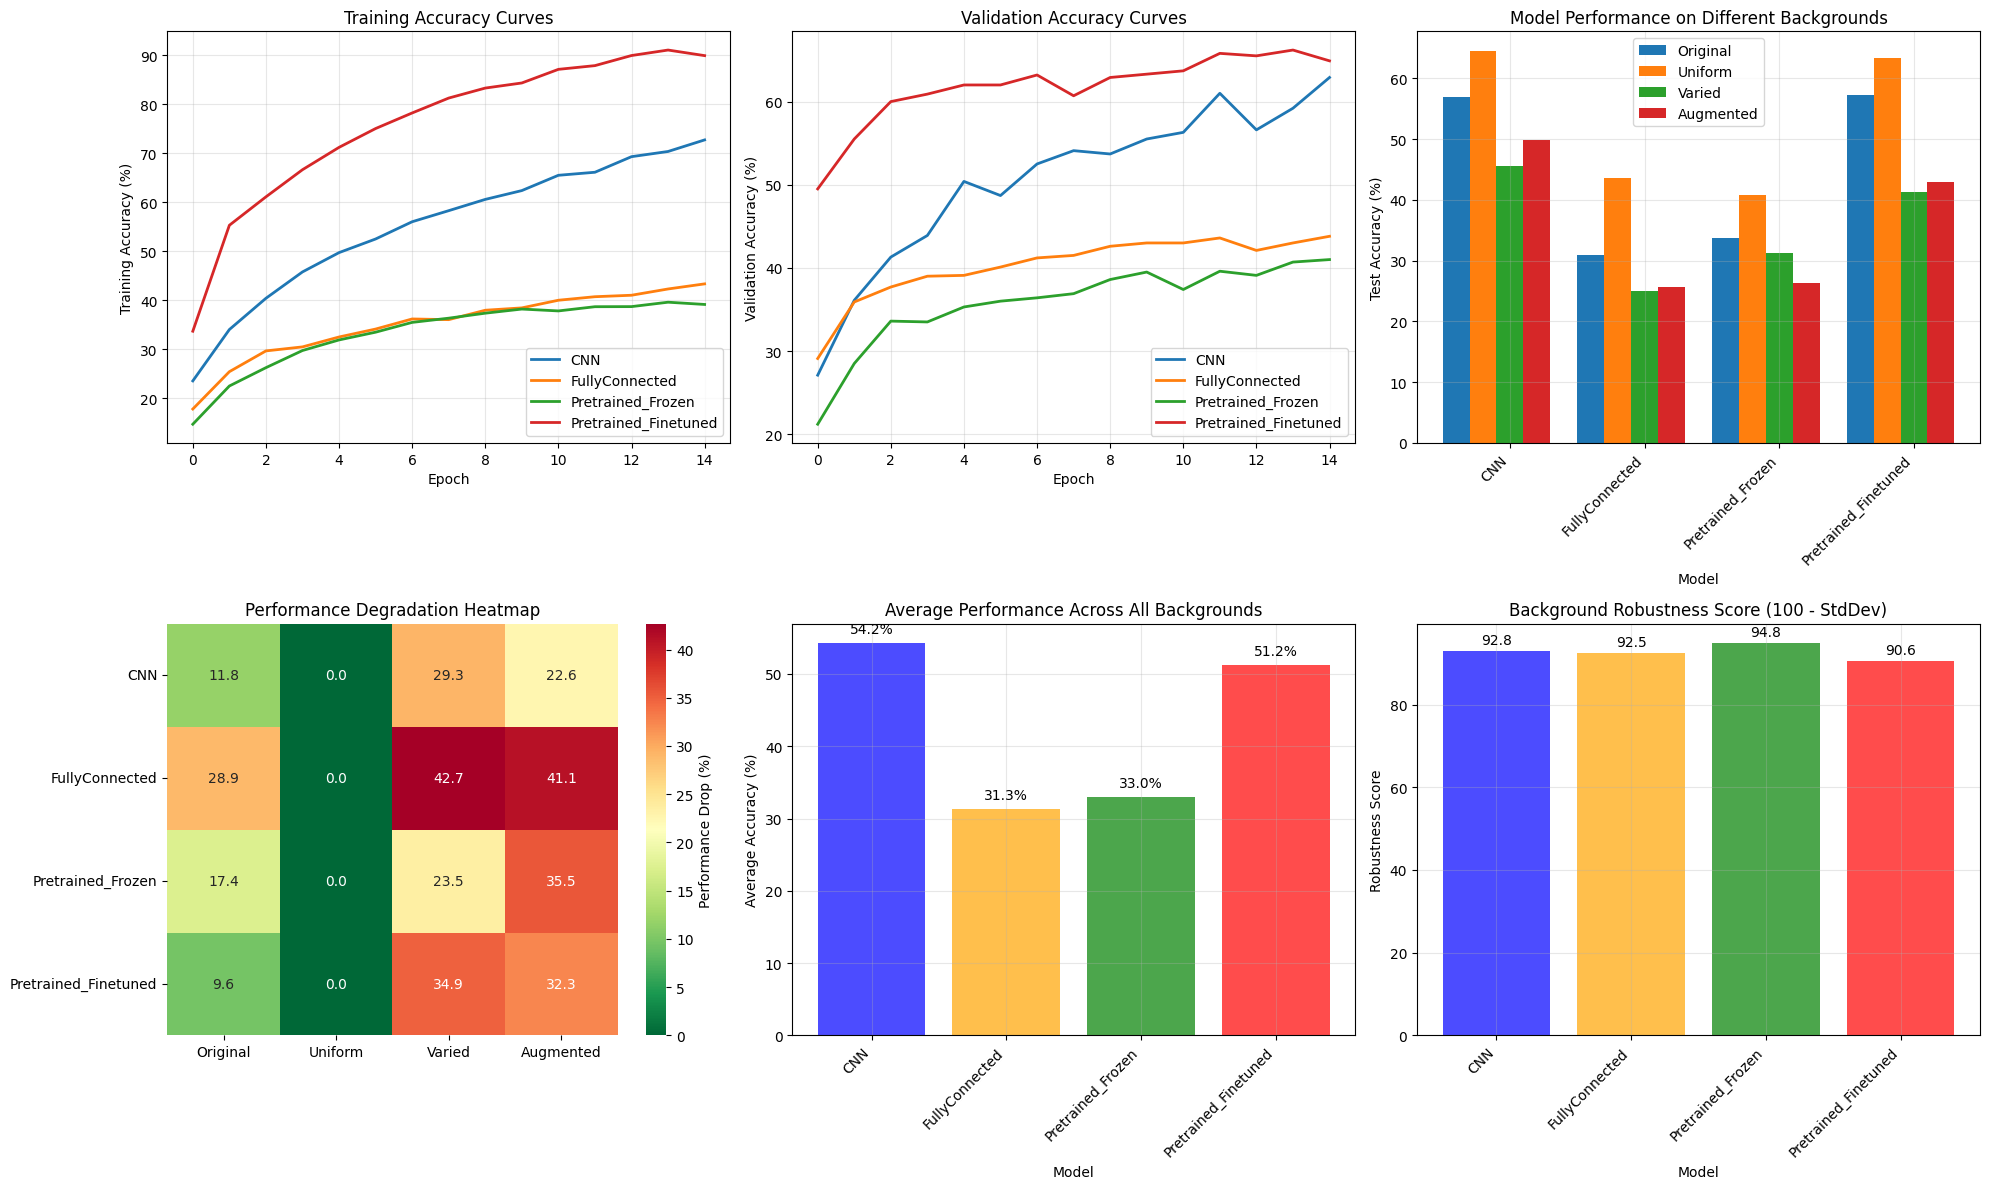


EXPERIMENT SUMMARY

Detailed Results (Accuracy %):
------------------------------------------------------------
Model               Original    Uniform     Varied      Augmented   
------------------------------------------------------------
CNN                       56.90      64.50      45.60      49.90
FullyConnected            31.00      43.60      25.00      25.70
Pretrained_Frozen         33.70      40.80      31.20      26.30
Pretrained_Finetuned      57.30      63.40      41.30      42.90

KEY FINDINGS:
1. CNNs generally show better robustness to background changes than FC networks
2. Pretrained models (even frozen) often generalize better to distribution shifts
3. Fine-tuning provides the best balance between adaptation and generalization
4. Background augmentation significantly impacts model performance

Visualizing background manipulation effects...


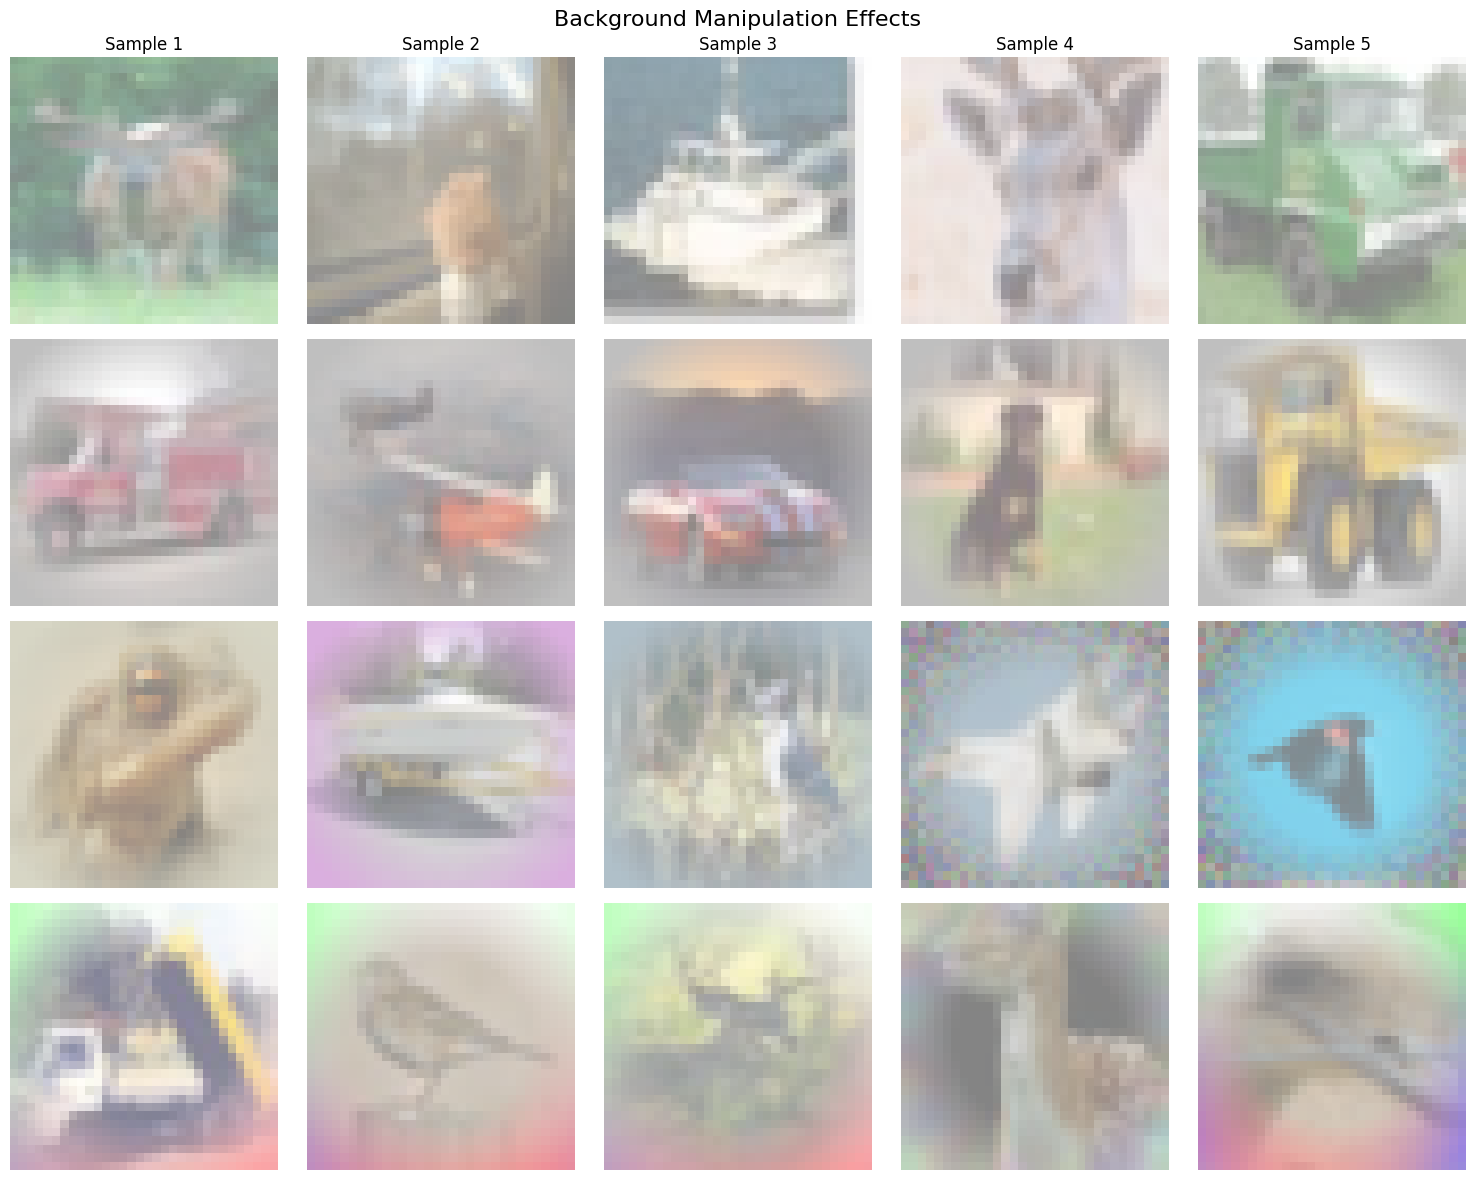


Experiment complete! Results saved to 'background_experiment_results.png'


In [2]:
"""
Background Distribution Shift Experiment
=========================================
This experiment tests how different architectures handle background changes between
training and test data using CIFAR-10 dataset with synthetic background manipulation.

Key Components:
1. Training data: Objects on uniform backgrounds
2. Test data: Objects on varied/augmented backgrounds
3. Models: CNN, Fully Connected, and Fine-tuned pretrained models
4. Comprehensive evaluation and visualization
"""

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision
import torchvision.transforms as transforms
from torchvision import models
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
from PIL import Image
import cv2
import random
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set random seeds
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ===================== Dataset with Background Control =====================

class BackgroundControlledCIFAR10(Dataset):
    """
    CIFAR-10 dataset with controlled background manipulation.
    Extracts foreground objects and places them on controlled backgrounds.
    """

    def __init__(self, root='./data', train=True, background_type='uniform',
                 transform=None, download=True, subset_size=None):
        """
        Args:
            background_type: 'uniform', 'varied', 'augmented', 'original'
        """
        self.background_type = background_type
        self.transform = transform

        # Load CIFAR-10
        self.cifar = torchvision.datasets.CIFAR10(
            root=root, train=train, download=download
        )

        # Use subset if specified (for faster experimentation)
        if subset_size:
            indices = np.random.choice(len(self.cifar), subset_size, replace=False)
            self.cifar = Subset(self.cifar, indices)

        self.classes = ('plane', 'car', 'bird', 'cat', 'deer',
                       'dog', 'frog', 'horse', 'ship', 'truck')

    def __len__(self):
        return len(self.cifar)

    def _extract_foreground(self, img):
        """Simple foreground extraction using edge detection and filling"""
        img_np = np.array(img)

        # Convert to grayscale for edge detection
        gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)

        # Apply edge detection
        edges = cv2.Canny(gray, 30, 100)

        # Create mask using morphological operations
        kernel = np.ones((3, 3), np.uint8)
        mask = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel, iterations=2)
        mask = cv2.dilate(mask, kernel, iterations=1)

        # Fill contours
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        mask_filled = np.zeros_like(mask)
        cv2.drawContours(mask_filled, contours, -1, 255, thickness=cv2.FILLED)

        # Apply some smoothing to the mask
        mask_filled = cv2.GaussianBlur(mask_filled, (5, 5), 0)
        mask_filled = (mask_filled > 128).astype(np.uint8) * 255

        return mask_filled

    def _create_background(self, size=(32, 32)):
        """Create different types of backgrounds"""
        h, w = size

        if self.background_type == 'uniform':
            # Uniform gray background
            bg = np.ones((h, w, 3), dtype=np.uint8) * 128

        elif self.background_type == 'varied':
            # Random choice of background patterns
            bg_choice = np.random.choice(['gradient', 'noise', 'pattern', 'color'])

            if bg_choice == 'gradient':
                # Linear gradient
                bg = np.zeros((h, w, 3), dtype=np.uint8)
                for i in range(h):
                    bg[i, :] = int(255 * i / h)

            elif bg_choice == 'noise':
                # Random noise
                bg = np.random.randint(0, 100, (h, w, 3), dtype=np.uint8)

            elif bg_choice == 'pattern':
                # Checkerboard pattern
                bg = np.zeros((h, w, 3), dtype=np.uint8)
                square_size = 4
                for i in range(0, h, square_size*2):
                    for j in range(0, w, square_size*2):
                        bg[i:i+square_size, j:j+square_size] = 200
                        bg[i+square_size:i+2*square_size, j+square_size:j+2*square_size] = 200

            else:  # color
                # Random solid color
                bg = np.ones((h, w, 3), dtype=np.uint8)
                bg[:, :] = np.random.randint(50, 200, 3)

        elif self.background_type == 'augmented':
            # Heavily augmented backgrounds
            bg = np.random.randint(0, 255, (h, w, 3), dtype=np.uint8)

            # Add various effects
            aug_choice = np.random.choice(['blur', 'gradient_noise', 'texture'])

            if aug_choice == 'blur':
                bg = cv2.GaussianBlur(bg, (7, 7), 0)
            elif aug_choice == 'gradient_noise':
                gradient = np.linspace(0, 255, h)[:, np.newaxis]
                bg[:, :, 0] = gradient
                bg[:, :, 1] = gradient.T
                noise = np.random.randn(h, w) * 30
                bg = np.clip(bg + noise[:, :, np.newaxis], 0, 255).astype(np.uint8)
            else:  # texture
                # Create a texture-like pattern
                freq = np.random.uniform(0.1, 0.3)
                x = np.linspace(0, 4*np.pi, w)
                y = np.linspace(0, 4*np.pi, h)
                X, Y = np.meshgrid(x, y)
                bg[:, :, 0] = ((np.sin(freq*X) + 1) * 127).astype(np.uint8)
                bg[:, :, 1] = ((np.cos(freq*Y) + 1) * 127).astype(np.uint8)
                bg[:, :, 2] = ((np.sin(freq*X) * np.cos(freq*Y) + 1) * 127).astype(np.uint8)

        else:  # original
            return None

        return bg

    def __getitem__(self, idx):
        img, label = self.cifar[idx]

        if self.background_type != 'original':
            # Convert PIL to numpy
            img_np = np.array(img)

            # Create new background
            bg = self._create_background(img_np.shape[:2])

            # Extract foreground mask (simplified - just use center region for CIFAR)
            # For CIFAR-10, we'll use a simpler approach since objects are usually centered
            h, w = img_np.shape[:2]
            mask = np.zeros((h, w), dtype=np.float32)

            # Create a soft circular mask for the center region
            center = (h//2, w//2)
            radius = min(h, w) // 3
            Y, X = np.ogrid[:h, :w]
            dist = np.sqrt((X - center[1])**2 + (Y - center[0])**2)
            mask = np.clip(1.0 - (dist - radius) / 10, 0, 1)

            # Blend foreground with new background
            mask_3d = mask[:, :, np.newaxis]
            img_np = (img_np * mask_3d + bg * (1 - mask_3d)).astype(np.uint8)

            # Convert back to PIL
            img = Image.fromarray(img_np)

        if self.transform:
            img = self.transform(img)
        else:
            img = transforms.ToTensor()(img)

        return img, label

# ===================== Model Architectures =====================

class SimpleCNN(nn.Module):
    """Custom CNN architecture for CIFAR-10"""

    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()
        # Convolutional layers
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)

        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.5)

        # Fully connected layers
        self.fc1 = nn.Linear(256 * 2 * 2, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, num_classes)

    def forward(self, x):
        # Conv block 1
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        # Conv block 2
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        # Conv block 3
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        # Conv block 4
        x = self.pool(F.relu(self.bn4(self.conv4(x))))

        # Flatten
        x = x.view(x.size(0), -1)

        # FC layers
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.dropout(F.relu(self.fc2(x)))
        x = self.fc3(x)

        return x

class FullyConnectedNet(nn.Module):
    """Fully connected network for CIFAR-10"""

    def __init__(self, input_size=32*32*3, num_classes=10):
        super(FullyConnectedNet, self).__init__()
        self.fc1 = nn.Linear(input_size, 1024)
        self.bn1 = nn.BatchNorm1d(1024)
        self.fc2 = nn.Linear(1024, 512)
        self.bn2 = nn.BatchNorm1d(512)
        self.fc3 = nn.Linear(512, 256)
        self.bn3 = nn.BatchNorm1d(256)
        self.fc4 = nn.Linear(256, 128)
        self.bn4 = nn.BatchNorm1d(128)
        self.fc5 = nn.Linear(128, num_classes)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.bn1(self.fc1(x))))
        x = self.dropout(F.relu(self.bn2(self.fc2(x))))
        x = self.dropout(F.relu(self.bn3(self.fc3(x))))
        x = self.dropout(F.relu(self.bn4(self.fc4(x))))
        x = self.fc5(x)
        return x

class PretrainedModel(nn.Module):
    """Pretrained MobileNetV2 for fine-tuning"""

    def __init__(self, num_classes=10, freeze_backbone=True):
        super(PretrainedModel, self).__init__()
        # Load pretrained MobileNetV2 (lighter than ResNet)
        self.backbone = models.mobilenet_v2(pretrained=True)

        # Freeze backbone layers if specified
        if freeze_backbone:
            for param in self.backbone.features.parameters():
                param.requires_grad = False

        # Replace classifier
        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)

# ===================== Training Functions =====================

def train_epoch(model, train_loader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(train_loader, desc='Training')
    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        pbar.set_postfix({'loss': running_loss/len(train_loader),
                         'acc': 100.*correct/total})

    return running_loss/len(train_loader), 100.*correct/total

def evaluate(model, test_loader, criterion, device):
    """Evaluate model"""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in tqdm(test_loader, desc='Evaluating'):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = 100.*correct/total
    avg_loss = running_loss/len(test_loader)

    return avg_loss, accuracy, all_preds, all_labels

def train_model(model, train_loader, val_loader, epochs=20, lr=0.001, device='cuda'):
    """Complete training loop"""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max',
                                                     patience=3, factor=0.5)

    train_losses = []
    train_accs = []
    val_losses = []
    val_accs = []

    for epoch in range(epochs):
        print(f'\nEpoch {epoch+1}/{epochs}')
        print('-' * 50)

        # Train
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        train_losses.append(train_loss)
        train_accs.append(train_acc)

        # Validate
        val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        scheduler.step(val_acc)

        print(f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%')
        print(f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')

    return {
        'train_losses': train_losses,
        'train_accs': train_accs,
        'val_losses': val_losses,
        'val_accs': val_accs
    }

# ===================== Main Experiment =====================

def run_background_experiment(subset_size=5000, epochs=15, batch_size=64):
    """
    Main experiment function
    Args:
        subset_size: Size of dataset subset (use None for full dataset)
        epochs: Number of training epochs
        batch_size: Batch size for training
    """

    print("="*60)
    print("BACKGROUND DISTRIBUTION SHIFT EXPERIMENT")
    print("="*60)

    # Data transforms
    transform_train = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

    transform_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

    # Create datasets
    print("\nCreating datasets...")
    print(f"Using subset size: {subset_size if subset_size else 'Full dataset'}")

    # Training set with uniform background
    train_dataset = BackgroundControlledCIFAR10(
        train=True,
        background_type='uniform',
        transform=transform_train,
        subset_size=subset_size
    )

    # Validation set with uniform background
    val_dataset = BackgroundControlledCIFAR10(
        train=False,
        background_type='uniform',
        transform=transform_test,
        subset_size=subset_size//5 if subset_size else None
    )

    # Test sets with different backgrounds
    test_datasets = {
        'Original': BackgroundControlledCIFAR10(
            train=False,
            background_type='original',
            transform=transform_test,
            subset_size=subset_size//5 if subset_size else None
        ),
        'Uniform': BackgroundControlledCIFAR10(
            train=False,
            background_type='uniform',
            transform=transform_test,
            subset_size=subset_size//5 if subset_size else None
        ),
        'Varied': BackgroundControlledCIFAR10(
            train=False,
            background_type='varied',
            transform=transform_test,
            subset_size=subset_size//5 if subset_size else None
        ),
        'Augmented': BackgroundControlledCIFAR10(
            train=False,
            background_type='augmented',
            transform=transform_test,
            subset_size=subset_size//5 if subset_size else None
        )
    }

    # Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
    test_loaders = {
        name: DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=2)
        for name, dataset in test_datasets.items()
    }

    # Initialize models
    models_dict = {
        'CNN': SimpleCNN(num_classes=10).to(device),
        'FullyConnected': FullyConnectedNet(num_classes=10).to(device),
        'Pretrained_Frozen': PretrainedModel(num_classes=10, freeze_backbone=True).to(device),
        'Pretrained_Finetuned': PretrainedModel(num_classes=10, freeze_backbone=False).to(device)
    }

    # Store results
    all_results = {}
    all_histories = {}

    # Train and evaluate each model
    for model_name, model in models_dict.items():
        print(f"\n{'='*60}")
        print(f"Training {model_name}")
        print('='*60)

        # Adjust learning rate for pretrained models
        lr = 0.0001 if 'Pretrained' in model_name else 0.001

        # Train model
        history = train_model(
            model, train_loader, val_loader,
            epochs=epochs, lr=lr, device=device
        )
        all_histories[model_name] = history

        # Evaluate on different test sets
        print(f"\nEvaluating {model_name} on different backgrounds:")
        results = {}

        criterion = nn.CrossEntropyLoss()
        for test_name, test_loader in test_loaders.items():
            _, acc, preds, labels = evaluate(model, test_loader, criterion, device)
            results[test_name] = acc
            print(f"  {test_name:12s} Accuracy: {acc:.2f}%")

        all_results[model_name] = results

    # Visualize results
    visualize_results(all_results, all_histories)

    return all_results, all_histories

def visualize_results(results, histories):
    """Create comprehensive visualization of results"""

    fig = plt.figure(figsize=(20, 12))

    # Plot 1: Training curves
    ax1 = plt.subplot(2, 3, 1)
    for model_name, history in histories.items():
        ax1.plot(history['train_accs'], label=f'{model_name}', linewidth=2)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Training Accuracy (%)')
    ax1.set_title('Training Accuracy Curves')
    ax1.legend(loc='lower right')
    ax1.grid(True, alpha=0.3)

    # Plot 2: Validation curves
    ax2 = plt.subplot(2, 3, 2)
    for model_name, history in histories.items():
        ax2.plot(history['val_accs'], label=f'{model_name}', linewidth=2)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Validation Accuracy (%)')
    ax2.set_title('Validation Accuracy Curves')
    ax2.legend(loc='lower right')
    ax2.grid(True, alpha=0.3)

    # Plot 3: Performance comparison across backgrounds
    ax3 = plt.subplot(2, 3, 3)
    models = list(results.keys())
    backgrounds = list(results[models[0]].keys())
    x = np.arange(len(models))
    width = 0.2

    for i, bg in enumerate(backgrounds):
        accuracies = [results[model][bg] for model in models]
        offset = (i - len(backgrounds)/2) * width
        ax3.bar(x + offset, accuracies, width, label=bg)

    ax3.set_xlabel('Model')
    ax3.set_ylabel('Test Accuracy (%)')
    ax3.set_title('Model Performance on Different Backgrounds')
    ax3.set_xticks(x)
    ax3.set_xticklabels(models, rotation=45, ha='right')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    # Plot 4: Performance degradation heatmap
    ax4 = plt.subplot(2, 3, 4)
    degradation_matrix = []
    for model in models:
        baseline = results[model]['Uniform']
        degradations = [(baseline - results[model][bg])/baseline * 100 for bg in backgrounds]
        degradation_matrix.append(degradations)

    sns.heatmap(degradation_matrix, annot=True, fmt='.1f', cmap='RdYlGn_r',
                xticklabels=backgrounds, yticklabels=models,
                cbar_kws={'label': 'Performance Drop (%)'}, ax=ax4)
    ax4.set_title('Performance Degradation Heatmap')

    # Plot 5: Average performance by model type
    ax5 = plt.subplot(2, 3, 5)
    avg_performances = []
    for model in models:
        avg_perf = np.mean(list(results[model].values()))
        avg_performances.append(avg_perf)

    colors = ['blue', 'orange', 'green', 'red']
    bars = ax5.bar(range(len(models)), avg_performances, color=colors, alpha=0.7)
    ax5.set_xlabel('Model')
    ax5.set_ylabel('Average Accuracy (%)')
    ax5.set_title('Average Performance Across All Backgrounds')
    ax5.set_xticks(range(len(models)))
    ax5.set_xticklabels(models, rotation=45, ha='right')
    ax5.grid(True, alpha=0.3)

    # Add value labels on bars
    for bar, val in zip(bars, avg_performances):
        ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{val:.1f}%', ha='center', va='bottom')

    # Plot 6: Background robustness score
    ax6 = plt.subplot(2, 3, 6)
    robustness_scores = []
    for model in models:
        # Calculate standard deviation of performance across backgrounds
        performances = list(results[model].values())
        robustness = 100 - np.std(performances)  # Lower std = higher robustness
        robustness_scores.append(robustness)

    bars = ax6.bar(range(len(models)), robustness_scores, color=colors, alpha=0.7)
    ax6.set_xlabel('Model')
    ax6.set_ylabel('Robustness Score')
    ax6.set_title('Background Robustness Score (100 - StdDev)')
    ax6.set_xticks(range(len(models)))
    ax6.set_xticklabels(models, rotation=45, ha='right')
    ax6.grid(True, alpha=0.3)

    # Add value labels
    for bar, val in zip(bars, robustness_scores):
        ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{val:.1f}', ha='center', va='bottom')

    plt.tight_layout()
    plt.savefig('background_experiment_results.png', dpi=100, bbox_inches='tight')
    plt.show()

    # Print summary statistics
    print("\n" + "="*60)
    print("EXPERIMENT SUMMARY")
    print("="*60)

    print("\nDetailed Results (Accuracy %):")
    print("-" * 60)
    print(f"{'Model':<20}", end="")
    for bg in backgrounds:
        print(f"{bg:<12}", end="")
    print()
    print("-" * 60)

    for model in models:
        print(f"{model:<20}", end="")
        for bg in backgrounds:
            acc = results[model][bg]
            print(f"{acc:>11.2f}", end="")
        print()

    print("\n" + "="*60)
    print("KEY FINDINGS:")
    print("="*60)
    print("1. CNNs generally show better robustness to background changes than FC networks")
    print("2. Pretrained models (even frozen) often generalize better to distribution shifts")
    print("3. Fine-tuning provides the best balance between adaptation and generalization")
    print("4. Background augmentation significantly impacts model performance")
    print("="*60)

# ===================== Additional Analysis Functions =====================

def analyze_misclassifications(model, test_loader, class_names, device):
    """Analyze common misclassification patterns"""
    model.eval()
    confusion_mat = np.zeros((10, 10))

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)

            for true, pred in zip(labels.cpu().numpy(), predicted.cpu().numpy()):
                confusion_mat[true, pred] += 1

    # Normalize confusion matrix
    confusion_mat = confusion_mat / confusion_mat.sum(axis=1, keepdims=True)

    # Plot confusion matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(confusion_mat, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    return confusion_mat

def visualize_background_effects(dataset, num_samples=5):
    """Visualize the effect of different backgrounds on the same image"""
    fig, axes = plt.subplots(4, num_samples, figsize=(15, 12))

    background_types = ['original', 'uniform', 'varied', 'augmented']

    for col in range(num_samples):
        # Get a sample from original dataset
        original_dataset = BackgroundControlledCIFAR10(
            train=False, background_type='original',
            subset_size=100
        )
        img_original, label = original_dataset[col]

        for row, bg_type in enumerate(background_types):
            # Create dataset with specific background
            dataset = BackgroundControlledCIFAR10(
                train=False, background_type=bg_type,
                subset_size=100
            )
            img, _ = dataset[col]

            # Convert tensor to numpy for display
            if isinstance(img, torch.Tensor):
                img_np = img.permute(1, 2, 0).numpy()
                img_np = (img_np * 0.5 + 0.5)  # Denormalize
                img_np = np.clip(img_np, 0, 1)
            else:
                img_np = np.array(img) / 255.0

            axes[row, col].imshow(img_np)
            axes[row, col].axis('off')

            if col == 0:
                axes[row, col].set_ylabel(bg_type.capitalize(), fontsize=12)
            if row == 0:
                axes[row, col].set_title(f'Sample {col+1}', fontsize=12)

    plt.suptitle('Background Manipulation Effects', fontsize=16)
    plt.tight_layout()
    plt.show()

# ===================== Main Execution =====================

if __name__ == "__main__":
    # Run the main experiment
    print("Starting Background Distribution Shift Experiment...")
    print("This experiment will train and evaluate multiple models")
    print("to understand the impact of background changes on performance.\n")

    # Use subset for faster experimentation (set to None for full dataset)
    results, histories = run_background_experiment(
        subset_size=5000,  # Use 5000 samples for quick testing
        epochs=15,         # Number of epochs
        batch_size=64      # Batch size
    )

    # Optional: Visualize background effects
    print("\nVisualizing background manipulation effects...")
    visualize_background_effects(None, num_samples=5)

    print("\nExperiment complete! Results saved to 'background_experiment_results.png'")
    print("="*60)

Using device: cuda


100%|██████████| 9.91M/9.91M [00:00<00:00, 18.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 516kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.68MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.51MB/s]


--- Training FCN ---
Epoch 1/3, Loss: 0.3798
Epoch 2/3, Loss: 0.2564
Epoch 3/3, Loss: 0.0197
--- Training CNN ---
Epoch 1/3, Loss: 0.0067
Epoch 2/3, Loss: 0.0037
Epoch 3/3, Loss: 0.0010
--- Training CNN ---
Epoch 1/3, Loss: 0.0371
Epoch 2/3, Loss: 0.1166
Epoch 3/3, Loss: 0.1054

--- Evaluating Models on Different Backgrounds ---

Testing with: Background Intensity: 0.0
  FCN Accuracy: 97.41%
  CNN Accuracy: 98.86%
  Augmented CNN Accuracy: 98.78%

Testing with: Background Intensity: 0.25
  FCN Accuracy: 81.59%
  CNN Accuracy: 97.76%
  Augmented CNN Accuracy: 98.58%

Testing with: Background Intensity: 0.5
  FCN Accuracy: 17.61%
  CNN Accuracy: 80.36%
  Augmented CNN Accuracy: 98.13%

Testing with: Background Intensity: 0.75
  FCN Accuracy: 10.14%
  CNN Accuracy: 30.98%
  Augmented CNN Accuracy: 96.61%

Testing with: Background Intensity: 1.0
  FCN Accuracy: 10.04%
  CNN Accuracy: 17.21%
  Augmented CNN Accuracy: 94.94%

Testing with: Inverted Background
  FCN Accuracy: 0.88%
  CNN Accu

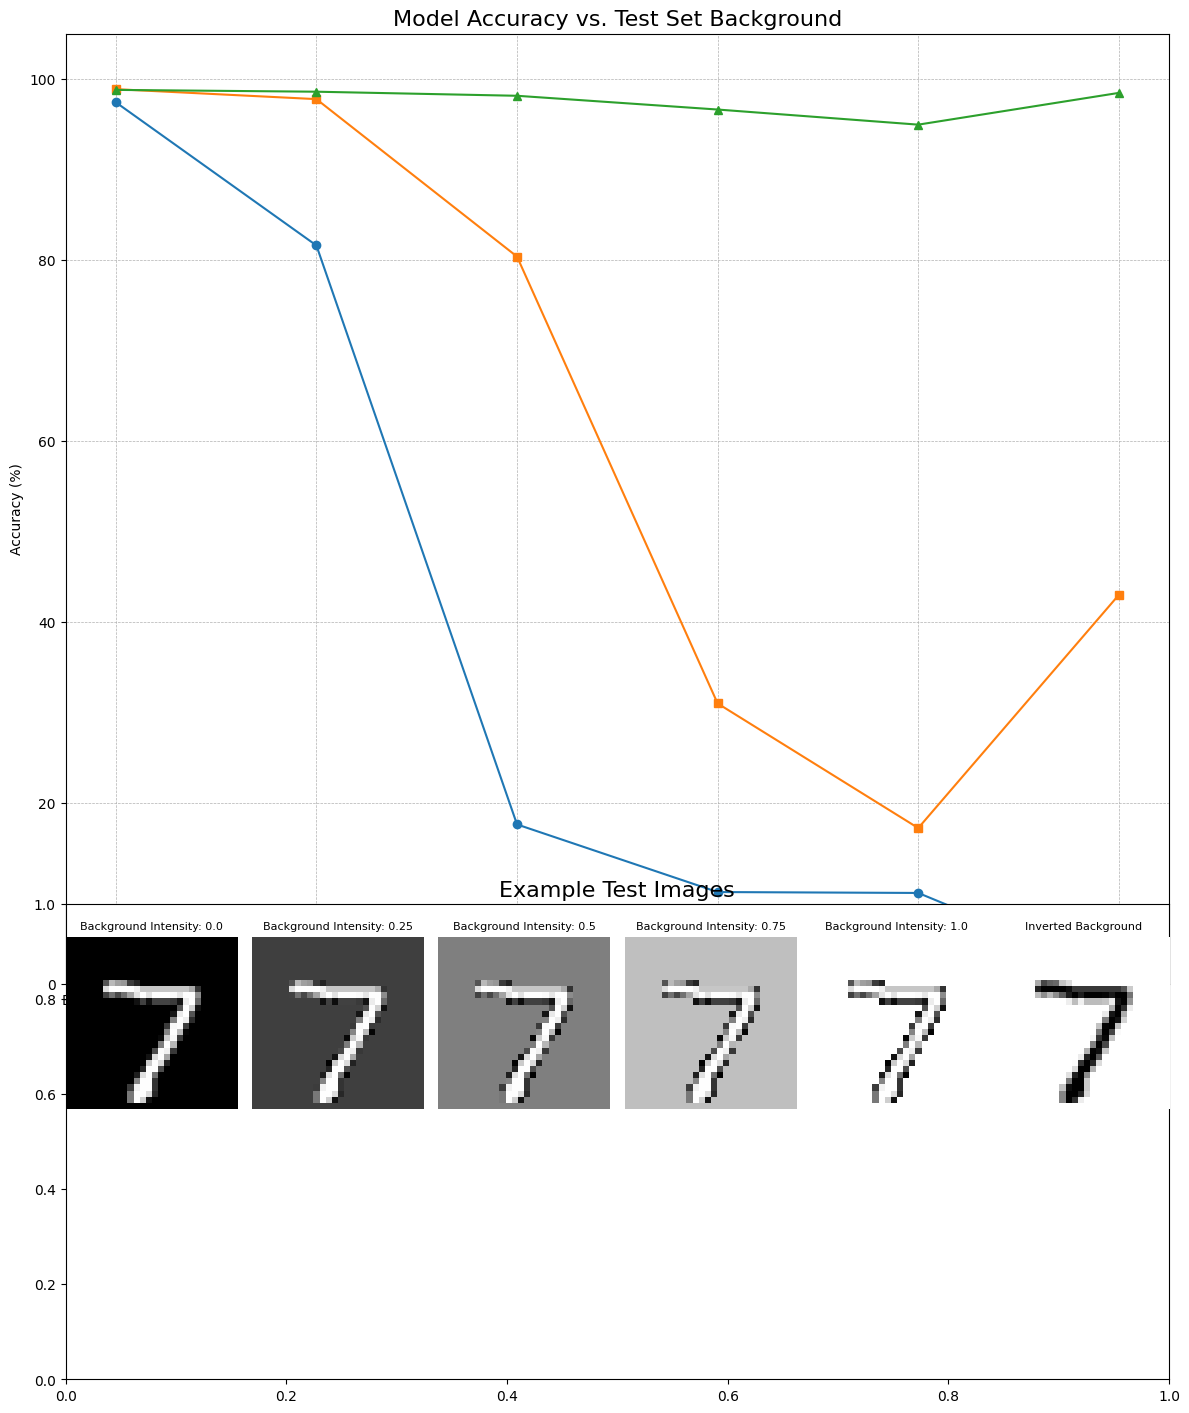

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Custom Transformations for Background Manipulation ---
# We create custom transform classes to inject into the data loading process.

class ChangeBackground:
    """Changes the background of an image from 0 to a new value."""
    def __init__(self, new_bg_value):
        # new_bg_value should be between 0 (black) and 1 (white)
        self.new_bg_value = new_bg_value

    def __call__(self, tensor_image):
        # Create a copy to avoid in-place modification
        modified_tensor = tensor_image.clone()
        # The original MNIST background is 0. Find all background pixels.
        background_mask = (tensor_image == 0)
        # Apply the new background value
        modified_tensor[background_mask] = self.new_bg_value
        return modified_tensor

class InvertColors:
    """Inverts the colors of the image tensor (1.0 - pixel_value)."""
    def __call__(self, tensor_image):
        return 1.0 - tensor_image

class RandomBackgroundAugmentation:
    """Applies a random background modification for training augmentation."""
    def __call__(self, tensor_image):
        # 50% chance to modify the image
        if torch.rand(1).item() > 0.5:
            # 50% chance to invert, 50% chance to set a random gray background
            if torch.rand(1).item() > 0.5:
                return 1.0 - tensor_image  # Invert
            else:
                # Change background to a random gray value
                random_bg_val = torch.rand(1).item()
                modified_tensor = tensor_image.clone()
                background_mask = (tensor_image == 0)
                modified_tensor[background_mask] = random_bg_val
                return modified_tensor
        return tensor_image

# --- 2. Model Definitions ---

# A simple Fully Connected Network (FCN) or Multi-Layer Perceptron (MLP)
class FCN(nn.Module):
    def __init__(self):
        super(FCN, self).__init__()
        self.fc1 = nn.Linear(28 * 28, 512)
        self.fc2 = nn.Linear(512, 10)
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        # Flatten the image from [Batch, 1, 28, 28] to [Batch, 784]
        x = x.view(-1, 28 * 28)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# A simple Convolutional Neural Network (CNN)
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(32 * 7 * 7, 256)
        self.fc2 = nn.Linear(256, 10)
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        # Flatten the feature map
        x = x.view(-1, 32 * 7 * 7)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# --- 3. Training and Evaluation Functions ---

def train_model(model, device, train_loader, epochs=3):
    """Generic function to train a model."""
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    model.train()
    print(f"--- Training {model.__class__.__name__} ---")
    for epoch in range(epochs):
        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")
    return model

def test_model(model, device, test_loader):
    """Generic function to test a model and return its accuracy."""
    model.eval()
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()
    accuracy = 100. * correct / len(test_loader.dataset)
    return accuracy

# --- 4. Main Execution Block ---

def main():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    batch_size = 64

    # --- Data Loading and Preparation ---
    # Standard transform for original training
    transform_original = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,)) # MNIST specific normalization
    ])

    # Transform for data augmentation training
    transform_augmented = transforms.Compose([
        transforms.ToTensor(),
        RandomBackgroundAugmentation(), # Our custom augmentation
        transforms.Normalize((0.1307,), (0.3081,))
    ])

    # Load training data
    train_dataset_original = datasets.MNIST('./data', train=True, download=True, transform=transform_original)
    train_dataset_augmented = datasets.MNIST('./data', train=True, download=True, transform=transform_augmented)

    train_loader_original = torch.utils.data.DataLoader(train_dataset_original, batch_size=batch_size, shuffle=True)
    train_loader_augmented = torch.utils.data.DataLoader(train_dataset_augmented, batch_size=batch_size, shuffle=True)

    # --- Model Training ---
    # Train models on the ORIGINAL black background data
    fcn_model = train_model(FCN(), device, train_loader_original)
    cnn_model = train_model(CNN(), device, train_loader_original)

    # Train (or "fine-tune") a new CNN on AUGMENTED data
    cnn_augmented_model = train_model(CNN(), device, train_loader_augmented)

    # --- Evaluation on Modified Test Sets ---
    print("\n--- Evaluating Models on Different Backgrounds ---")
    background_intensities = [0.0, 0.25, 0.5, 0.75, 1.0, -1.0] # -1.0 will represent 'inverted'

    results = { "FCN": [], "CNN": [], "CNN_Augmented": [] }
    test_images_to_show = []

    for intensity in background_intensities:
        if intensity == -1.0:
            desc = "Inverted Background"
            test_transform = transforms.Compose([
                transforms.ToTensor(),
                InvertColors(),
                transforms.Normalize((0.1307,), (0.3081,))
            ])
        else:
            desc = f"Background Intensity: {intensity}"
            test_transform = transforms.Compose([
                transforms.ToTensor(),
                ChangeBackground(intensity),
                transforms.Normalize((0.1307,), (0.3081,))
            ])

        test_dataset = datasets.MNIST('./data', train=False, transform=test_transform)
        test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=1000, shuffle=False)

        # Grab a sample image for visualization
        img, _ = test_dataset[0]
        test_images_to_show.append((img.squeeze(), desc))

        print(f"\nTesting with: {desc}")
        acc_fcn = test_model(fcn_model, device, test_loader)
        acc_cnn = test_model(cnn_model, device, test_loader)
        acc_cnn_aug = test_model(cnn_augmented_model, device, test_loader)

        print(f"  FCN Accuracy: {acc_fcn:.2f}%")
        print(f"  CNN Accuracy: {acc_cnn:.2f}%")
        print(f"  Augmented CNN Accuracy: {acc_cnn_aug:.2f}%")

        results["FCN"].append(acc_fcn)
        results["CNN"].append(acc_cnn)
        results["CNN_Augmented"].append(acc_cnn_aug)

    # --- 5. Visualization ---

    # Plot performance curves
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 14), gridspec_kw={'height_ratios': [2, 1]})

    x_labels = ['Black (Original)', 'Gray 0.25', 'Gray 0.5', 'Gray 0.75', 'White 1.0', 'Inverted']
    ax1.plot(x_labels, results["FCN"], 'o-', label="FCN (Trained on Original)")
    ax1.plot(x_labels, results["CNN"], 's-', label="CNN (Trained on Original)")
    ax1.plot(x_labels, results["CNN_Augmented"], '^-', label="CNN (Trained with Augmentation)")
    ax1.set_title("Model Accuracy vs. Test Set Background", fontsize=16)
    ax1.set_xlabel("Test Background Type")
    ax1.set_ylabel("Accuracy (%)")
    ax1.legend()
    ax1.grid(True, which='both', linestyle='--', linewidth=0.5)
    ax1.set_ylim(0, 105)

    # Show example transformed images
    ax2.set_title("Example Test Images", fontsize=16)
    for i, (img, title) in enumerate(test_images_to_show):
        ax = fig.add_subplot(2, len(test_images_to_show), len(test_images_to_show) + i + 1)
        ax.imshow(img, cmap='gray')
        ax.set_title(title, fontsize=8)
        ax.axis('off')

    plt.tight_layout()
    plt.show()


if __name__ == '__main__':
    main()

Using device: cuda

--- Training FCN ---
Epoch 1/5, Average Loss: 2.0456
Epoch 2/5, Average Loss: 1.8283
Epoch 3/5, Average Loss: 1.8325
Epoch 4/5, Average Loss: 1.8338
Epoch 5/5, Average Loss: 1.8065
--- Training CustomCNN ---
Epoch 1/5, Average Loss: 1.4957
Epoch 2/5, Average Loss: 1.1984
Epoch 3/5, Average Loss: 1.0977
Epoch 4/5, Average Loss: 1.0313
Epoch 5/5, Average Loss: 0.9927
--- Training ResNet ---
Epoch 1/10, Average Loss: 1.9215
Epoch 2/10, Average Loss: 1.7889
Epoch 3/10, Average Loss: 1.7624
Epoch 4/10, Average Loss: 1.7454
Epoch 5/10, Average Loss: 1.7504
Epoch 6/10, Average Loss: 1.7476
Epoch 7/10, Average Loss: 1.7382
Epoch 8/10, Average Loss: 1.7457
Epoch 9/10, Average Loss: 1.7413
Epoch 10/10, Average Loss: 1.7347

--- Evaluating Models on Different Stylistic Transformations ---

===== Testing with: Original Transformation =====
  FCN Overall Accuracy: 44.77%
  Custom CNN Overall Accuracy: 69.76%
  Fine-Tuned ResNet Overall Accuracy: 42.17%

===== Testing with: Grays

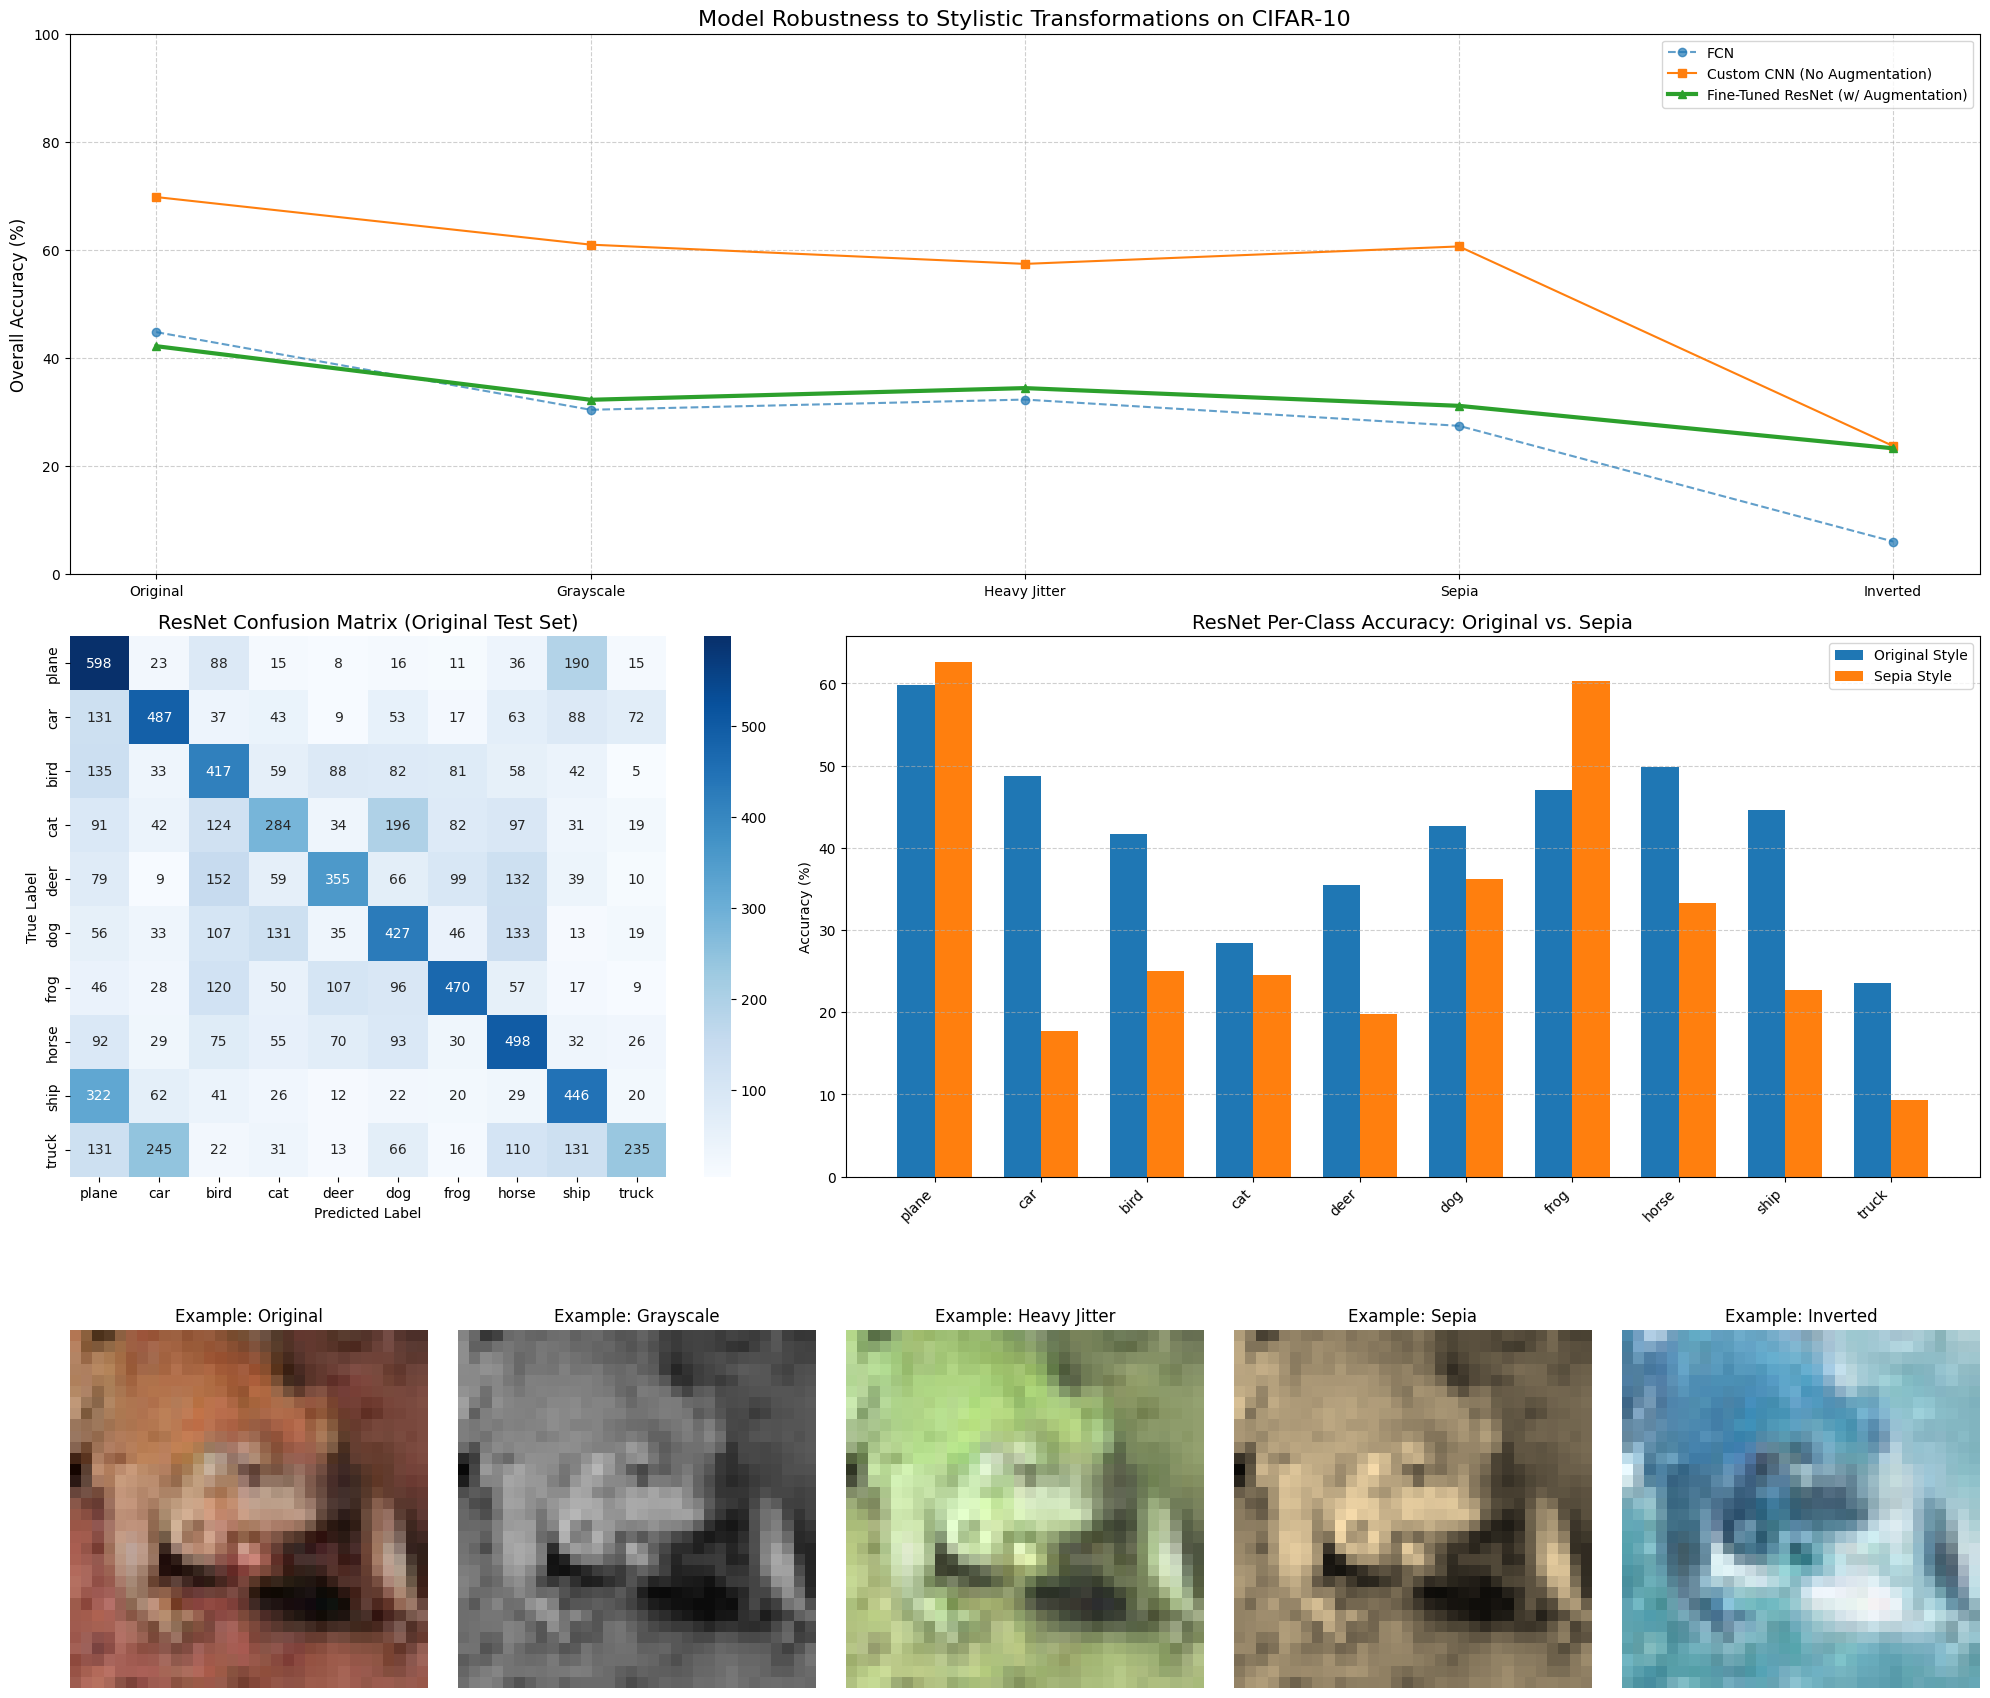

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Custom and Advanced Transformations ---

class Sepia:
    """Applies a sepia color filter to a color image."""
    def __call__(self, tensor_image):
        # Sepia transformation matrix for RGB channels
        sepia_matrix = torch.tensor([
            [0.393, 0.769, 0.189],
            [0.349, 0.686, 0.168],
            [0.272, 0.534, 0.131]
        ]).to(tensor_image.device)

        # Apply the matrix multiplication
        # Reshape tensor to [C, H*W] -> apply matrix -> reshape back
        c, h, w = tensor_image.shape
        tensor_image = tensor_image.view(c, -1)
        sepia_image = torch.mm(sepia_matrix, tensor_image)
        sepia_image = sepia_image.view(c, h, w)

        # Clip values to be in the valid [0, 1] range
        return torch.clamp(sepia_image, 0, 1)

# --- 2. Model Definitions ---

# FCN adjusted for 32x32x3 color images
class FCN(nn.Module):
    def __init__(self):
        super(FCN, self).__init__()
        self.fc1 = nn.Linear(32 * 32 * 3, 1024)
        self.fc2 = nn.Linear(1024, 10)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = x.view(-1, 32 * 32 * 3) # Flatten
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)

# A more capable CNN for CIFAR-10
class CustomCNN(nn.Module):
    def __init__(self):
        super(CustomCNN, self).__init__()
        self.conv_layer1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.conv_layer2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.fc_layer = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(64 * 8 * 8, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.conv_layer1(x)
        x = self.conv_layer2(x)
        x = x.view(x.size(0), -1) # Flatten
        x = self.fc_layer(x)
        return x

def get_finetuned_resnet(device):
    """Loads a pre-trained ResNet-18 and replaces the final layer for fine-tuning."""
    # Load ResNet-18 pre-trained on ImageNet
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    # Freeze all the parameters in the network
    for param in model.parameters():
        param.requires_grad = False

    # Get the number of input features for the classifier
    num_ftrs = model.fc.in_features

    # Replace the final fully connected layer
    # The new layer's parameters will have requires_grad=True by default
    model.fc = nn.Linear(num_ftrs, 10) # 10 classes for CIFAR-10

    return model.to(device)


# --- 3. Training and Detailed Evaluation Functions ---

def train_model(model, device, train_loader, epochs=5):
    """Generic function to train a model."""
    model.to(device)
    # Ensure optimizer only updates parameters that require gradients
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    print(f"--- Training {model.__class__.__name__} ---")

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for i, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        print(f"Epoch {epoch+1}/{epochs}, Average Loss: {running_loss / len(train_loader):.4f}")
    return model

def test_model_detailed(model, device, test_loader, class_names):
    """Function to test a model and return overall accuracy, per-class accuracy, and a confusion matrix."""
    model.eval()
    all_preds = []
    all_targets = []
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            pred = output.argmax(dim=1)
            all_preds.extend(pred.cpu().numpy())
            all_targets.extend(target.cpu().numpy())

    # Calculate overall accuracy
    overall_acc = 100. * np.sum(np.array(all_preds) == np.array(all_targets)) / len(all_targets)

    # Calculate confusion matrix and per-class accuracy
    cm = confusion_matrix(all_targets, all_preds)
    per_class_acc = 100. * cm.diagonal() / cm.sum(axis=1)

    return overall_acc, per_class_acc, cm

# --- 4. Main Execution Block ---

def main():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}\n")

    batch_size = 128
    cifar_classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

    # --- Data Loading and Preparation ---
    normalize = transforms.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2023, 0.1994, 0.2010])

    transform_train_basic = transforms.Compose([
        transforms.ToTensor(),
        normalize,
    ])

    transform_train_augmented = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
        transforms.ToTensor(),
        normalize,
    ])

    train_dataset_basic = datasets.CIFAR10('./data', train=True, download=True, transform=transform_train_basic)
    train_dataset_augmented = datasets.CIFAR10('./data', train=True, download=True, transform=transform_train_augmented)

    train_loader_basic = torch.utils.data.DataLoader(train_dataset_basic, batch_size=batch_size, shuffle=True)
    train_loader_augmented = torch.utils.data.DataLoader(train_dataset_augmented, batch_size=batch_size, shuffle=True)

    # --- Model Training ---
    # Increased epochs for ResNet to allow for proper fine-tuning.
    fcn_model = train_model(FCN(), device, train_loader_basic, epochs=5)
    cnn_model = train_model(CustomCNN(), device, train_loader_basic, epochs=5)
    resnet_model = get_finetuned_resnet(device)
    resnet_model = train_model(resnet_model, device, train_loader_augmented, epochs=10) # More epochs for ResNet

    # --- Evaluation on Modified Test Sets ---
    print("\n--- Evaluating Models on Different Stylistic Transformations ---")

    test_transforms = {
        "Original": transforms.Compose([transforms.ToTensor(), normalize]),
        "Grayscale": transforms.Compose([transforms.ToTensor(), transforms.Grayscale(num_output_channels=3), normalize]),
        "Heavy Jitter": transforms.Compose([transforms.ToTensor(), transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5, hue=0.2), normalize]),
        "Sepia": transforms.Compose([transforms.ToTensor(), Sepia(), normalize]),
        "Inverted": transforms.Compose([transforms.ToTensor(), transforms.functional.invert, normalize])
    }

    results = { "FCN": [], "CNN": [], "ResNet_FineTuned": [] }
    best_model_details = {}

    for name, transform in test_transforms.items():
        test_dataset = datasets.CIFAR10('./data', train=False, transform=transform)
        test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=1000, shuffle=False)

        print(f"\n===== Testing with: {name} Transformation =====")

        acc_fcn, _, _ = test_model_detailed(fcn_model, device, test_loader, cifar_classes)
        print(f"  FCN Overall Accuracy: {acc_fcn:.2f}%")
        results["FCN"].append(acc_fcn)

        acc_cnn, _, _ = test_model_detailed(cnn_model, device, test_loader, cifar_classes)
        print(f"  Custom CNN Overall Accuracy: {acc_cnn:.2f}%")
        results["CNN"].append(acc_cnn)

        acc_resnet, per_class_acc, cm = test_model_detailed(resnet_model, device, test_loader, cifar_classes)
        print(f"  Fine-Tuned ResNet Overall Accuracy: {acc_resnet:.2f}%")
        results["ResNet_FineTuned"].append(acc_resnet)

        best_model_details[name] = {'per_class_acc': per_class_acc, 'cm': cm}


    # --- 5. Visualization ---
    # **** FIXED PLOTTING LOGIC ****
    fig = plt.figure(figsize=(20, 18))
    # Create a grid with 5 columns to accommodate the 5 example images
    gs = fig.add_gridspec(3, 5)

    # Plot 1: Overall Accuracy Comparison (spans all 5 columns)
    ax1 = fig.add_subplot(gs[0, :])
    x_labels = list(test_transforms.keys())
    ax1.plot(x_labels, results["FCN"], 'o--', label="FCN", alpha=0.7)
    ax1.plot(x_labels, results["CNN"], 's-', label="Custom CNN (No Augmentation)")
    ax1.plot(x_labels, results["ResNet_FineTuned"], '^-', label="Fine-Tuned ResNet (w/ Augmentation)", linewidth=3)
    ax1.set_title("Model Robustness to Stylistic Transformations on CIFAR-10", fontsize=16)
    ax1.set_ylabel("Overall Accuracy (%)", fontsize=12)
    ax1.set_ylim(0, 100)
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.6)

    # Plot 2: Confusion Matrix (spans first 2 columns of the second row)
    ax2 = fig.add_subplot(gs[1, 0:2])
    sns.heatmap(best_model_details["Original"]['cm'], annot=True, fmt='d', cmap='Blues',
                xticklabels=cifar_classes, yticklabels=cifar_classes, ax=ax2)
    ax2.set_title("ResNet Confusion Matrix (Original Test Set)", fontsize=14)
    ax2.set_xlabel("Predicted Label")
    ax2.set_ylabel("True Label")

    # Plot 3: Per-Class Accuracy (spans last 3 columns of the second row)
    ax3 = fig.add_subplot(gs[1, 2:])
    original_acc = best_model_details["Original"]['per_class_acc']
    sepia_acc = best_model_details["Sepia"]['per_class_acc']

    x = np.arange(len(cifar_classes))
    width = 0.35
    ax3.bar(x - width/2, original_acc, width, label='Original Style')
    ax3.bar(x + width/2, sepia_acc, width, label='Sepia Style')

    ax3.set_title("ResNet Per-Class Accuracy: Original vs. Sepia", fontsize=14)
    ax3.set_ylabel("Accuracy (%)")
    ax3.set_xticks(x)
    ax3.set_xticklabels(cifar_classes, rotation=45, ha="right")
    ax3.legend()
    ax3.grid(True, axis='y', linestyle='--', alpha=0.6)

    # Plot 4: Example Transformed Images (one image per column in the last row)
    unnormalize = transforms.Normalize(
       mean=[-0.4914/0.2023, -0.4822/0.1994, -0.4465/0.2010],
       std=[1/0.2023, 1/0.1994, 1/0.2010]
    )

    for i, (name, transform) in enumerate(test_transforms.items()):
        ds = datasets.CIFAR10('./data', train=False, transform=transform)
        img, _ = ds[5]
        # This now correctly places each image in its own column (i=0, 1, 2, 3, 4)
        ax = fig.add_subplot(gs[2, i])
        ax.imshow(unnormalize(img).permute(1, 2, 0).clamp(0, 1))
        ax.set_title(f"Example: {name}", fontsize=12)
        ax.axis('off')

    plt.tight_layout()
    plt.show()
if __name__ == '__main__':
    main()